In [1]:
from rdkit import Chem

smi = "N3(C)[C@@H](C1CCCC1)C(=O)N(C)[C@H](C(=O)N(C)C)CC(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H]([C@H](CC)C)C(=O)N(C)[C@@H](C)C(=O)N1[C@@H](CC1)C(=O)N[C@@H]([C@H](NC(=O)Cn1c(N)nnn1)C(=O)O)C(=O)N(C)CC(=O)N[C@@H](C(=O)N[C@H]1CN(C)NC1=O)C(=O)N1[C@@H](CCC1)C(=O)NC1(CCCC1)C3(=O)"

mol = Chem.MolFromSmiles(smi)

writer = Chem.SDWriter("peptide.sdf")
writer.write(mol)
writer.close()

In [2]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

smi = "N[C@H](C=O)[C@@H](C(O)=O)NC(CN1C(N)=NN=N1)=O"
mol = Chem.MolFromSmiles(smi)
# Calculate LogP
logp, mr = rdMolDescriptors.CalcCrippenDescriptors(mol)
print(f"LogP: {logp}, MR: {mr}")

LogP: -3.649099999999999, MR: 55.83529999999999


In [3]:
smi = "CNCC=O"
mol = Chem.MolFromSmiles(smi)
# Calculate LogP
logp, mr = rdMolDescriptors.CalcCrippenDescriptors(mol)
print(f"LogP: {logp}, MR: {mr}")

LogP: -0.5953000000000002, MR: 19.990699999999997


In [7]:
chuckle = "N3(C)[C@@H](CC(C)C)C(=O)|N[C@@H]([C@H](CC)C)C(=O)|N(C)[C@@H](C)C(=O)|N1[C@@H](CC1)C(=O)|N[C@@H]([C@H](NC(=O)Cn1c(N)nnn1)C(=O)O)C(=O)|N(C)CC(=O)|N[C@@H](C(=O)N[C@H]1CN(C)NC1=O)C(=O)|N1[C@@H](CCC1)C(=O)|NC1(CCCC1)C(=O)|N(C)[C@@H](C1CCCC1)C(=O)|N(C)[C@H](C(=O)N(C)C)CC3(=O)"
smiles_list = [s.replace("N3(", "N(").replace("CC3(=O)", "CC(=O)") for s in chuckle.split("|")]

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# -----------------------------
# 1) JCIM-style rcParams
# -----------------------------
def set_jcim_style():
    mpl.rcParams.update({
        # Font
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # Font sizes
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8.5,

        # Lines
        "axes.linewidth": 0.9,
        "lines.linewidth": 1.6,
        "lines.markersize": 5,

        # Ticks
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
        "xtick.minor.size": 2.0,
        "ytick.minor.size": 2.0,
        "xtick.minor.width": 0.7,
        "ytick.minor.width": 0.7,
        "xtick.direction": "out",
        "ytick.direction": "out",

        # Export
        "figure.dpi": 100,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    })

set_jcim_style()


# -----------------------------
# 2) Final figure sizes
# -----------------------------
SINGLE_COL_IN = 4
H_MED   = 3.4


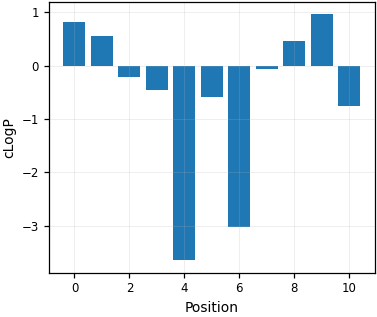

In [8]:
from rdkit import Chem
from rdkit.Chem import Crippen
import matplotlib.pyplot as plt

# Compute logP for each position
logp_values = []
positions = []

for i, smi in enumerate(smiles_list):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        logp = float("nan")
    else:
        logp = Crippen.MolLogP(mol)
    positions.append(i)
    logp_values.append(logp)


# Plot
plt.figure(figsize=(SINGLE_COL_IN, H_MED))
plt.bar(positions, logp_values)
plt.xlabel("Position")
plt.ylabel("cLogP")
plt.grid(True, which="major", axis="both", alpha=0.25, linewidth=0.6)
plt.tight_layout()
plt.savefig("clogp_by_position.pdf")
